# Vanilla RNN on **Text Sequences** with Keras

This notebook shows how to apply a **Vanilla RNN** (via `keras.layers.SimpleRNN`) to **text sequences** for a tiny **sentiment classification** task.

## What you'll learn
1. Build a toy **text classification** dataset (positive/negative sentiment).
2. **Tokenize** text → **integer sequences**; inspect the word-index mapping.
3. **Pad** sequences to a fixed length `(samples, timesteps)`.
4. Build a **Vanilla RNN**: `Embedding → SimpleRNN → Dense`.
5. Train, evaluate, and test the model on new sentences.
6. Visualize **per-timestep** outputs with `return_sequences=True` for intuition.



In [1]:
!pip install keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.9 MB/s eta 0:00:00


In [2]:
# --- Imports (Keras-first) ---
import os
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers, models, optimizers, losses, metrics
#from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences

# Show which backend Keras is using (TensorFlow by default if available)
try:
    backend_name = keras.config.backend()
except Exception:
    # Older Keras fallback
    import keras.backend as K
    backend_name = getattr(K, 'backend', lambda: 'unknown')()
print("Keras backend:", backend_name)

np.random.seed(42)


Keras backend: tensorflow


## 1) Create a tiny sentiment dataset (self-contained)

We'll write a few dozen short sentences labeled **positive (1)** or **negative (0)**.  
This is intentionally small so we can **see** how tokenization and sequences work.


In [3]:
# --- Tiny toy dataset (positive/negative sentences) ---
positive_texts = [
    "I love this movie",
    "This film was fantastic",
    "What a great experience",
    "Absolutely wonderful story",
    "The acting was brilliant",
    "I really enjoyed the plot",
    "Such a beautiful soundtrack",
    "Amazing cinematography and visuals",
    "I am happy with the ending",
    "It was a delightful watch",
    "Superb and engaging",
    "Loved every moment",
    "Heartwarming and inspiring",
    "Marvelous direction",
    "Top notch performance"
]

negative_texts = [
    "I hate this movie",
    "This film was terrible",
    "What a bad experience",
    "Absolutely awful story",
    "The acting was horrible",
    "I really disliked the plot",
    "Such an ugly soundtrack",
    "Dreadful cinematography and visuals",
    "I am unhappy with the ending",
    "It was a boring watch",
    "Poor and uninteresting",
    "Hated every moment",
    "Depressing and annoying",
    "Terrible direction",
    "Very weak performance"
]

texts = positive_texts + negative_texts
labels = [1]*len(positive_texts) + [0]*len(negative_texts)
labels = np.array(labels, dtype=np.int32)

print("Total samples:", len(texts), "| Positives:", sum(labels), "| Negatives:", len(labels)-sum(labels))

# Shuffle to mix positives/negatives
idx = np.arange(len(texts))
np.random.shuffle(idx)
texts = [texts[i] for i in idx]
labels = labels[idx]


Total samples: 30 | Positives: 15 | Negatives: 15


## 2) Tokenize → integer sequences

We use `Tokenizer` to build a word-index dictionary and convert each sentence to a sequence of integers.


In [12]:
# --- Tokenize the text corpus ---
# num_words limits the vocabulary size. OOV (out-of-vocabulary) words map to a special token if configured.
vocab_size = 2000
tokenizer = Tokenizer(num_words=vocab_size, lower=True, oov_token="<oov>")
tokenizer.fit_on_texts(texts)

word_index = tokenizer.word_index
print("Vocabulary size (including OOV):", len(word_index))
print("Sample mapping (first 15):", dict(list(word_index.items())[:15]))

# Convert texts → sequences of word indices
sequences = tokenizer.texts_to_sequences(texts)
print("Example original text:", texts[0])
print("Tokenized sequence:", sequences[0])


Vocabulary size (including OOV): 65
Sample mapping (first 15): {'<oov>': 1, 'and': 2, 'i': 3, 'the': 4, 'was': 5, 'a': 6, 'this': 7, 'movie': 8, 'am': 9, 'with': 10, 'ending': 11, 'what': 12, 'experience': 13, 'it': 14, 'watch': 15}
Example original text: Depressing and annoying
Tokenized sequence: [31, 2, 32]


## 3) Pad sequences to a fixed length

RNNs expect input shape `(batch, timesteps, features)`.  
For word sequences, **features=embedding_dim** (which we'll learn).  
We first pad the integer sequences to a common **`max_len`**.


In [13]:
# --- Pad sequences ---
# Choose a reasonable fixed length for these short sentences.
max_len = 8
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print("Padded shape:", X.shape)   # (num_samples, max_len)
print("First padded sequence:", X[0])
print("Statement:", texts[0])

# Train/validation split
n = len(X)
split = int(0.8 * n)
X_train, y_train = X[:split], labels[:split]
X_val,   y_val   = X[split:], labels[split:]

print("Train size:", X_train.shape, "Val size:", X_val.shape)


Padded shape: (30, 8)
First padded sequence: [31  2 32  0  0  0  0  0]
Statement: Depressing and annoying
Train size: (24, 8) Val size: (6, 8)


## 4) Build a Vanilla RNN model

Architecture:  
**Embedding (learn word vectors) → SimpleRNN → Dense(1, sigmoid)** for binary sentiment.


In [14]:
# --- Build the Keras model ---
embedding_dim = 32

model = models.Sequential([
    # Embedding layer maps each token index to a dense vector (learned during training).
    layers.Embedding(input_dim=min(vocab_size, len(word_index)+1),
                     output_dim=embedding_dim,
                     input_length=max_len,
                     name="embedding"),

    # SimpleRNN processes one timestep at a time and returns the final hidden state by default.
    layers.SimpleRNN(16, name="vanilla_rnn"),

    # Output layer: binary classification (positive vs negative), hence sigmoid activation.
    layers.Dense(1, activation='sigmoid', name="classifier")
])

model.compile(optimizer=optimizers.Adam(1e-3),
              loss=losses.BinaryCrossentropy(),
              metrics=[metrics.BinaryAccuracy()])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn (SimpleRNN)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5) Train the model

Small dataset → a handful of epochs is enough for demonstration.  
We track **validation accuracy** to see if the model generalizes beyond the training set.


In [15]:
# --- Train ---
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=2
)


Epoch 1/12
3/3 - 2s - 804ms/step - binary_accuracy: 0.4583 - loss: 0.6974 - val_binary_accuracy: 0.6667 - val_loss: 0.6892
Epoch 2/12
3/3 - 0s - 31ms/step - binary_accuracy: 0.5417 - loss: 0.6837 - val_binary_accuracy: 0.5000 - val_loss: 0.7049
Epoch 3/12
3/3 - 0s - 31ms/step - binary_accuracy: 0.6667 - loss: 0.6753 - val_binary_accuracy: 0.5000 - val_loss: 0.7245
Epoch 4/12
3/3 - 0s - 31ms/step - binary_accuracy: 0.7083 - loss: 0.6626 - val_binary_accuracy: 0.3333 - val_loss: 0.7423
Epoch 5/12
3/3 - 0s - 32ms/step - binary_accuracy: 0.7500 - loss: 0.6506 - val_binary_accuracy: 0.1667 - val_loss: 0.7596
Epoch 6/12
3/3 - 0s - 31ms/step - binary_accuracy: 0.7500 - loss: 0.6387 - val_binary_accuracy: 0.0000e+00 - val_loss: 0.7784
Epoch 7/12
3/3 - 0s - 30ms/step - binary_accuracy: 0.8333 - loss: 0.6250 - val_binary_accuracy: 0.0000e+00 - val_loss: 0.8019
Epoch 8/12
3/3 - 0s - 37ms/step - binary_accuracy: 0.8750 - loss: 0.6092 - val_binary_accuracy: 0.0000e+00 - val_loss: 0.8285
Epoch 9/12


## 6) Plot training curves (loss & accuracy)

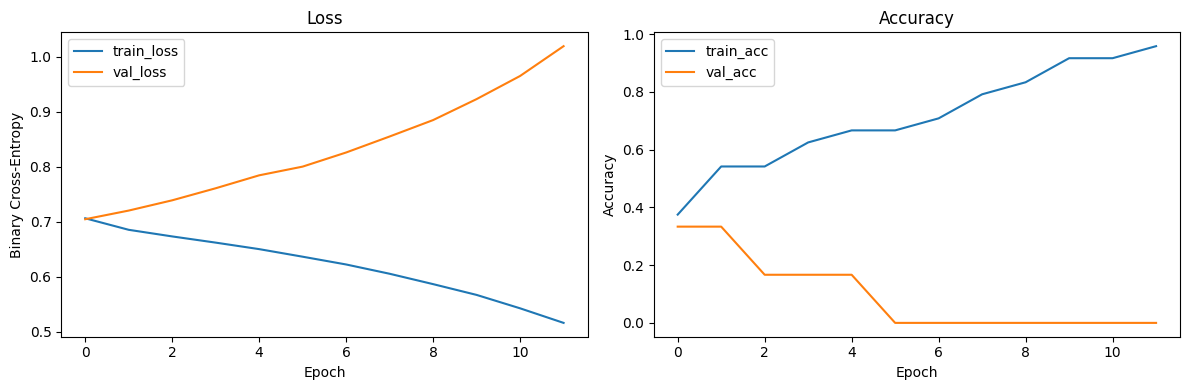

In [8]:
# --- Plot loss and accuracy ---
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['binary_accuracy'], label='train_acc')
plt.plot(history.history['val_binary_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 7) Try a few custom sentences

We'll reuse the same tokenizer and preprocessing, then call `model.predict(...)`.


In [16]:
# --- Inference helper ---
def preprocess_sentences(sent_list):
    # Convert raw sentences to padded integer sequences
    seqs = tokenizer.texts_to_sequences(sent_list)
    return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')

test_sentences = [
    "I absolutely loved the film",
    "The movie was not good",
    "What a fantastic performance",
    "Boring and weak direction",
    "Happy ending and great acting",
    "Terrible and depressing story"
]

X_test = preprocess_sentences(test_sentences)
probs = model.predict(X_test, verbose=0).squeeze()

for s, p in zip(test_sentences, probs):
    print(f"{s!r:45s} -> positive probability: {p:.3f}")


'I absolutely loved the film'                 -> positive probability: 0.487
'The movie was not good'                      -> positive probability: 0.557
'What a fantastic performance'                -> positive probability: 0.494
'Boring and weak direction'                   -> positive probability: 0.383
'Happy ending and great acting'               -> positive probability: 0.392
'Terrible and depressing story'               -> positive probability: 0.358


## 8) See **per-timestep** RNN outputs

To build intuition, we create a **second** model with `return_sequences=True` to see how the hidden state evolves as it reads tokens.


Model: "vis_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tokens_in (InputLayer)          │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_vis (Embedding)       │ (None, 8, 32)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn_vis (SimpleRNN)     │ (None, 8, 16)          │           784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,896 (11.31 KB)

 Trainable params: 2,896 (11.31 KB)

 Non-trainable params: 0 (0.00 B)

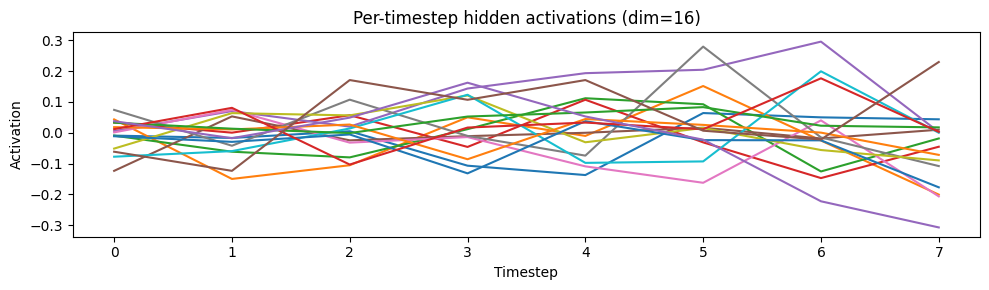

Token indices: [ 3 20 43  4 65  8  0  0]


In [17]:
# --- Build a second model for per-timestep visualization ---
embedding_layer = layers.Embedding(input_dim=min(vocab_size, len(word_index)+1),
                                   output_dim=embedding_dim,
                                   input_length=max_len,
                                   name="embedding_vis")

rnn_vis = layers.SimpleRNN(16, return_sequences=True, name="vanilla_rnn_vis")

inp = layers.Input(shape=(max_len,), name="tokens_in")
x = embedding_layer(inp)
x = rnn_vis(x)
vis_model = models.Model(inp, x, name="vis_model")
vis_model.summary()

# Pick one sample and see the hidden states across timesteps
sample = ["I really enjoyed the beautiful movie"]
X_sample = pad_sequences(tokenizer.texts_to_sequences(sample), maxlen=max_len, padding='post', truncating='post')
hidden_seq = vis_model.predict(X_sample, verbose=0)[0]  # shape: (timesteps, 16)

plt.figure(figsize=(10,3))
plt.plot(hidden_seq)
plt.title("Per-timestep hidden activations (dim=16)")
plt.xlabel("Timestep")
plt.ylabel("Activation")
plt.tight_layout()
plt.show()

print("Token indices:", X_sample[0])


In [11]:
sample1 = ["I really enjoyed the beautiful movie"]
X_sample1 = pad_sequences(tokenizer.texts_to_sequences(sample1), maxlen=max_len, padding='post', truncating='post')
hidden_seq1 = model.predict(X_sample1, verbose=0)[0]  # shape: (timesteps, 16)


for s, p in zip(sample1, hidden_seq1):
    print(f"{s!r:45s} -> positive probability: {p:.3f}")


'I really enjoyed the beautiful movie'        -> positive probability: 0.679


## Notes & Next Steps

- **Vanilla RNN** is good for pedagogy and **short** sequences.  
- For longer context or real-world NLP, prefer **GRU** or **LSTM**, or modern **Transformers**.
- Improve this toy demo by expanding the dataset, adding **regularization** (dropout), or using **pretrained embeddings** (e.g., GloVe) for better generalization (requires downloads).


In [20]:
import os

# --- Step 0: Save your notebook first! ---
print("Please save your notebook now (File -> Save) before proceeding.")

# --- Step 1: Initialize Git repository (if not already done) ---
# This will create a .git directory in your Colab environment's current working directory.
# Be cautious if you are already in a git-initialized directory or want to push only a part of the content.
!git init

# --- Step 2: Configure Git with your username and email (if not already done) ---
!git config --global user.email "YOUR_EMAIL@example.com" # Replace with your email
!git config --global user.name "YOUR_GITHUB_USERNAME" # Replace with your GitHub username

# --- Step 3: Add the current notebook file ---
# Colab notebooks are typically in the /content/ directory.
# You might need to adjust the filename if your notebook has a different name.
notebook_filename = 'Vanilla_RNN_on_Text_Sequences_with_Keras.ipynb' # <--- IMPORTANT: Verify this filename matches your saved notebook!

print(f"Checking for notebook file '{notebook_filename}'...")
!ls -F # Use -F to differentiate files and directories

!git add {notebook_filename}

# --- Step 4: Commit your changes ---
# This will only succeed if files were successfully added in the previous step.
!git commit -m "Initial commit: Vanilla RNN Text Sentiment Notebook"

# --- Step 5: Add the remote repository ---
# This step generated an 'error: remote origin already exists.' in the previous run.
# It's likely already configured. Only uncomment and run if you need to re-add/change the remote.
# remote_repo_url = "https://github.com/asbhosekar/Vanilla_RNN-.git"
# !git remote add origin {remote_repo_url}

# --- Step 6: Push to GitHub ---
# You will be prompted for your GitHub username and Personal Access Token (PAT).
# It's recommended to use a PAT instead of your password for security.
# Create one at https://github.com/settings/tokens
# Note: The default branch name created by 'git init' in Colab is often 'master', not 'main'.
# We've adjusted the push command accordingly.
!git push -u origin master # Use 'master' as it's the default branch name created by git init

Please save your notebook now (File -> Save) before proceeding.
Reinitialized existing Git repository in /content/.git/
Checking for notebook file 'Vanilla_RNN_on_Text_Sequences_with_Keras.ipynb'...
sample_data/
fatal: pathspec 'Vanilla_RNN_on_Text_Sequences_with_Keras.ipynb' did not match any files
On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec master does not match any
error: failed to push some refs to 'https://github.com/asbhosekar/Vanilla_RNN-.git'
